In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/household_data_15min_singleindex.csv")

print(df.shape)
df.head()

(153810, 71)


,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:45:00Z,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T18:15:00Z,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T18:30:00Z,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T18:45:00Z,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df["cet_cest_timestamp"] = pd.to_datetime(df["cet_cest_timestamp"])

In [5]:
df = df.set_index("cet_cest_timestamp")

In [6]:
df = df.sort_index()

In [7]:
print(df.index.dtype)
df.head()

object


,utc_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
cet_cest_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 18:45:00+01:00,2014-12-11T17:45:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+01:00,2014-12-11T18:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:15:00+01:00,2014-12-11T18:15:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:30:00+01:00,2014-12-11T18:30:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:45:00+01:00,2014-12-11T18:45:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
residential_ids = [1, 2, 3, 4, 5, 6]

In [9]:
load_df = pd.DataFrame(index=df.index)

In [10]:
for i in residential_ids:
    grid_import_col = f"DE_KN_residential{i}_grid_import"
    pv_col = f"DE_KN_residential{i}_pv"
    grid_export_col = f"DE_KN_residential{i}_grid_export"

    grid_import = df[grid_import_col] if grid_import_col in df.columns else 0.0
    pv = df[pv_col] if pv_col in df.columns else 0.0
    grid_export = df[grid_export_col] if grid_export_col in df.columns else 0.0

    load_df[f"residential{i}_load"] = grid_import + pv - grid_export

In [11]:
load_df.head()

,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
cet_cest_timestamp,,,,,,
2014-12-11 18:45:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:15:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:45:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
load_df.describe()

,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
count,63487.000000,63190.000000,47612.000000,81435.000000,123211.000000,66755.000000
mean,13779.846119,2017.367027,3733.514971,7611.200361,4690.002662,15442.822022
std,7420.930370,1276.663640,2179.448629,4300.431896,2612.395098,5262.700005
min,0.085000,0.000000,0.044000,0.013000,0.020000,6243.700000
25%,7929.616000,843.123250,1926.089500,4338.875500,2254.466000,11102.427000
50%,12720.016000,1988.908000,3637.930500,7114.778000,4758.691000,15420.064000
75%,21331.149500,3055.754250,5526.456750,11445.450000,7195.781500,20338.923000
max,25618.242000,4495.448000,8324.087000,15752.780000,8773.800000,24401.449000


In [13]:
load_df.max()

residential1_load    25618.242
residential2_load     4495.448
residential3_load     8324.087
residential4_load    15752.780
residential5_load     8773.800
residential6_load    24401.449
dtype: float64

In [14]:
load_df = load_df / 1000

In [15]:
load_df.describe()

,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
count,63487.000000,63190.000000,47612.000000,81435.000000,123211.000000,66755.000000
mean,13.779846,2.017367,3.733515,7.611200,4.690003,15.442822
std,7.420930,1.276664,2.179449,4.300432,2.612395,5.262700
min,0.000085,0.000000,0.000044,0.000013,0.000020,6.243700
25%,7.929616,0.843123,1.926090,4.338876,2.254466,11.102427
50%,12.720016,1.988908,3.637931,7.114778,4.758691,15.420064
75%,21.331149,3.055754,5.526457,11.445450,7.195781,20.338923
max,25.618242,4.495448,8.324087,15.752780,8.773800,24.401449


In [16]:
nan_summary = pd.DataFrame({
    "nan_count": load_df.isna().sum(),
    "nan_percent": 100 * load_df.isna().sum() / len(load_df)
})

nan_summary

,nan_count,nan_percent
residential1_load,90323,58.723750
residential2_load,90620,58.916845
residential3_load,106198,69.044926
residential4_load,72375,47.054808
residential5_load,30599,19.894025
residential6_load,87055,56.599051


In [17]:
house_data = {}

for i in residential_ids:
    
    col = f"residential{i}_load"
    
    house_df = load_df[[col]].dropna().copy()
    
    house_df = house_df.rename(columns={col: "load"})
    
    house_data[i] = house_df

In [18]:
for i in residential_ids:
    
    print(f"House {i}")
    print(house_data[i].shape)
    print()

House 1
(63487, 1)

House 2
(63190, 1)

House 3
(47612, 1)

House 4
(81435, 1)

House 5
(123211, 1)

House 6
(66755, 1)



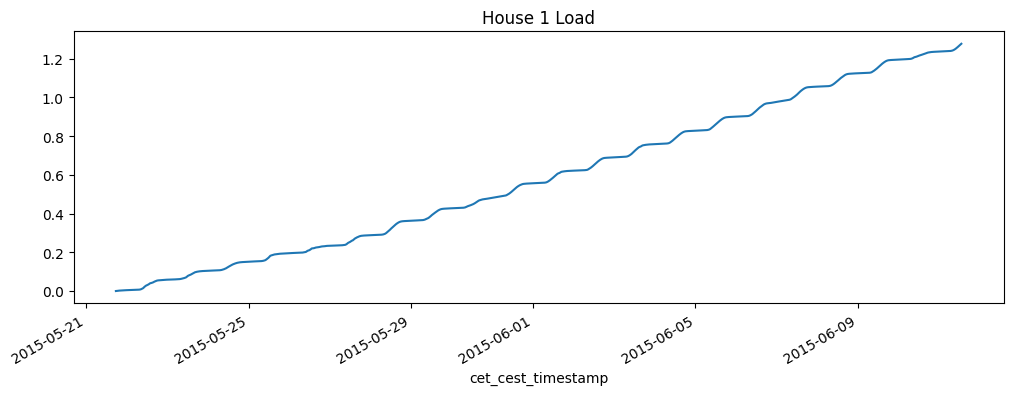

In [19]:
house_data[1]["load"].iloc[:2000].plot(figsize=(12,4))
plt.title("House 1 Load")
plt.show()

In [20]:
house_id = 1

grid_import_col = f"DE_KN_residential{house_id}_grid_import"
pv_col = f"DE_KN_residential{house_id}_pv"
grid_export_col = f"DE_KN_residential{house_id}_grid_export"

house1 = df[[grid_import_col]].copy()

if pv_col in df.columns:
    house1[pv_col] = df[pv_col]
else:
    house1[pv_col] = 0.0

if grid_export_col in df.columns:
    house1[grid_export_col] = df[grid_export_col]
else:
    house1[grid_export_col] = 0.0

house1 = house1.sort_index()
house1.head()

,DE_KN_residential1_grid_import,DE_KN_residential1_pv,DE_KN_residential1_grid_export
cet_cest_timestamp,,,
2014-12-11 18:45:00+01:00,NaN,NaN,0.0
2014-12-11 19:00:00+01:00,NaN,NaN,0.0
2014-12-11 19:15:00+01:00,NaN,NaN,0.0
2014-12-11 19:30:00+01:00,NaN,NaN,0.0
2014-12-11 19:45:00+01:00,NaN,NaN,0.0


In [21]:
house1_diff = house1.diff()
house1_diff.head()

,DE_KN_residential1_grid_import,DE_KN_residential1_pv,DE_KN_residential1_grid_export
cet_cest_timestamp,,,
2014-12-11 18:45:00+01:00,NaN,NaN,NaN
2014-12-11 19:00:00+01:00,NaN,NaN,0.0
2014-12-11 19:15:00+01:00,NaN,NaN,0.0
2014-12-11 19:30:00+01:00,NaN,NaN,0.0
2014-12-11 19:45:00+01:00,NaN,NaN,0.0


In [22]:
house1_diff["load"] = (
    house1_diff[grid_import_col]
    + house1_diff[pv_col]
    - house1_diff[grid_export_col]
)

In [23]:
house1_diff["load"] = house1_diff["load"].clip(lower=0)
house1_load = house1_diff[["load"]].dropna().copy()

house1_load.head()

,load
cet_cest_timestamp,
2015-05-21 17:45:00+02:00,0.157
2015-05-21 18:00:00+02:00,0.273
2015-05-21 18:15:00+02:00,0.311
2015-05-21 18:30:00+02:00,0.280
2015-05-21 18:45:00+02:00,0.265


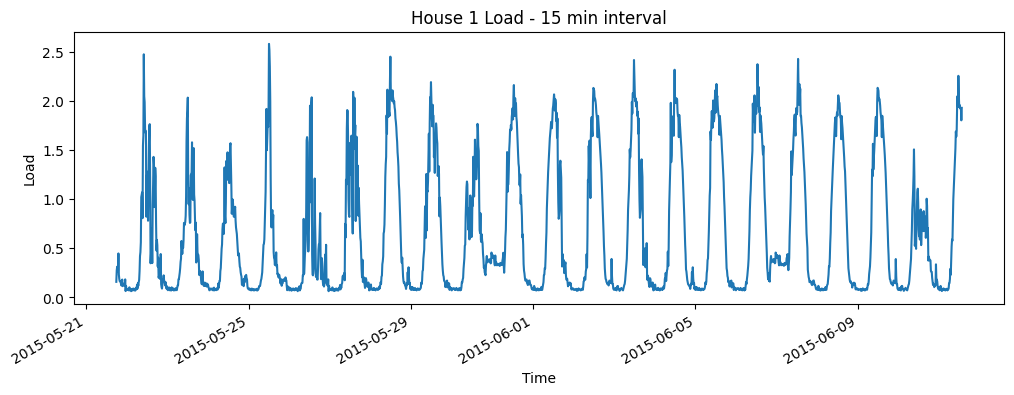

In [24]:
house1_load["load"].iloc[:2000].plot(figsize=(12, 4))
plt.title("House 1 Load - 15 min interval")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

In [25]:
house1_load["load"].describe()

count    63486.000000
mean         0.403525
std          0.502228
min          0.029000
25%          0.105000
50%          0.165000
75%          0.449000
max          3.198000
Name: load, dtype: float64

In [26]:
house1_load.index.to_series().diff().value_counts().head()

cet_cest_timestamp
0 days 00:15:00    63485
Name: count, dtype: int64

In [27]:
house_data = {}

for house_id in residential_ids:
    
    grid_import_col = f"DE_KN_residential{house_id}_grid_import"
    pv_col = f"DE_KN_residential{house_id}_pv"
    grid_export_col = f"DE_KN_residential{house_id}_grid_export"
    
    house_df = df[[grid_import_col]].copy()
    
    if pv_col in df.columns:
        house_df[pv_col] = df[pv_col]
    else:
        house_df[pv_col] = 0.0
        
    if grid_export_col in df.columns:
        house_df[grid_export_col] = df[grid_export_col]
    else:
        house_df[grid_export_col] = 0.0
    
    house_df = house_df.sort_index()
    
    house_diff = house_df.diff()
    
    house_diff["load"] = (
        house_diff[grid_import_col]
        + house_diff[pv_col]
        - house_diff[grid_export_col]
    )
    
    house_diff["load"] = house_diff["load"].clip(lower=0)
    
    house_load = house_diff[["load"]].dropna().copy()
    
    house_data[house_id] = house_load

In [28]:
for i in residential_ids:
    print(i, house_data[i].shape)

1 (63486, 1)
2 (63189, 1)
3 (47611, 1)
4 (81434, 1)
5 (123210, 1)
6 (66754, 1)
